# 6b Visualization differential abundance

In [1]:
library(readxl)
library(tidyverse)
library(RColorBrewer)
library(colorspace)
library(ggalluvial)
library(patchwork)
library(svglite) 
library(IRdisplay)
options(warn = -1)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


### Setup workspace

In [2]:
# Set working directory to project folder
wd <- "/path/to/02_metabolomics"
wd <- "/Net/Groups/pbtdata/07_DD/06_PPT/05_analysis/02_metabolomics"
setwd(wd)

### Define functions

In [3]:
process_file <- function(file, mz_features) {
  ms_data <- readMSData(files = file, mode = "onDisk", msLevel = 1)
  mode <- ifelse(grepl("*/pos/*", file), "pos", ifelse(grepl("*/neg/*", file), "neg", NA))
  if (is.na(mode)) stop("File mode not recognized")

  chrom <- chromatogram(ms_data, mz = mz_features[[mode]]$mz_ranges, aggregationFun = "max", missing = 0)
  eic_data_list <- lapply(seq_along(chrom), function(i) {
    data <- as.data.frame(chrom[[i]])
    data$filename <- basename(file)
    data$feature <- mz_features[[mode]]$features[i]
    data$target_mz <- mz_features[[mode]]$mz_ranges[i, 1]
    return(data)
  })

  return(do.call(rbind, eic_data_list))
}

# Function to calculate m/z ranges for a list of masses
calc_mz_ranges <- function(mz_list, ppm) {
  ranges <- sapply(mz_list, function(target_mz) {
    delta_mz <- target_mz * (ppm / 1e6)
    return(c(target_mz - delta_mz, target_mz + delta_mz))
  })
  return(t(ranges))
}


convert_to_min_sec <- function(minutes) {
  # Calculate whole minutes and remaining seconds
  whole_minutes <- floor(minutes)
  seconds <- round((minutes - whole_minutes) * 60)
  
  # Format the minutes and seconds with leading zeros
  formatted_time <- sprintf("%02dm%02ds", whole_minutes, seconds)
  
  return(formatted_time)
}

pad_number_float_string <- function(number_string, total_digits) {
  # Convert the number string to numeric and then to integer
  number_as_integer <- as.integer(as.numeric(number_string))
  
  # Format the integer with leading zeros up to the specified number of total digits
  formatted_number <- sprintf(paste0("%0", total_digits, "d"), number_as_integer)
  
  return(formatted_number)
}

### Define colors

In [20]:
down_colors <- brewer.pal(n = 9, name = "Blues")
up_colors <- brewer.pal(n = 9, name = "Reds")
change_colors <- c("down" = down_colors[4], "up" = up_colors[4], "none" = "darkgrey")
change_colors_dark <- c("down_dark" = down_colors[8], "up_dark" = up_colors[8], "none" = "none_dark")

change_alpha <- c("down" = 1, "up" = 1, "none" =1)

ClassyFire.superclass.colors <- c(
  "Organic nitrogen compounds" = "#8DD8C5",
  "Organic acids and derivatives" = "#fee366",
  "Nucleosides, nucleotides, and analogues" = "#7C94D3",
  "Lipids and lipid-like molecules" = "#F6AAC9",
  "unknown superclass" = "#CCCCCC",
  "Benzenoids" = "#F79A3E",
  "Organoheterocyclic compounds" = "#C9A556",
  "Organic 1,3-dipolar compounds" = "#B7E39B",
  "Phenylpropanoids and polyketides" = "#98C5E3",
  "Organic oxygen compounds" = "#F6A593",
  "Alkaloids and derivatives" = "#D4A6DA",
  "Organosulfur compounds" = "#D0EAD9",
  "Organometallic compounds" = "#FFF09B",
  "Organophosphorus compounds" = "#E0E0E0",
  "Organohalogen compounds" = "#F8C18B"
)

## 2 Load data

### Load feature table

In [6]:
ft_filePath <- file.path(wd, "03_analysis", "tables", "featureTable.csv")
ft <- read.csv(ft_filePath)

### Define parameters

In [7]:
pvalueTH         <- 0.01      # Significance threshold for statistical tests
log2fcTH         <- 2         # Absolute log2 fold change threshold for relevant features
samplePercentTH  <- 0.8       # Required presence in % of samples per group (e.g. 80%)
absentPercentTH  <- 0.15      # Max allowed presence in 'absent' group (e.g. 15%)
retentiontimeTH  <- 0.1       # Minimum retention time in minutes (to filter noise)
intTH            <- 100000    # Minimum intensity threshold for relevant features

### Preparing stage-specific feature tables
Creates a function to prepare a feature table for each developmental stage (vegetative, starved, fruiting body),  
selecting relevant columns, renaming them for consistency, and combining all stages into a single table.  
Also normalizes unknown superclass and class labels to improve downstream interpretation.


In [8]:
# Function to prepare feature table for a given stage
prepare_stage_table <- function(stage_name) {
  change_col   <- paste0("change_", stage_name)
  wt_mean_col  <- paste0(stage_name, "_wt_mean")
  pvalue_col   <- paste0(stage_name, "_pvalue")
  log2fc_col   <- paste0(stage_name, "_log2FC")
  
  ft %>%
    filter(.data[[change_col]] != "na") %>%
    select(
      feature, mode, mz, rt, rt_range.min, rt_range.max,
      !!sym(change_col), !!sym(wt_mean_col), !!sym(pvalue_col), !!sym(log2fc_col),
      sirius_NPC.pathway, sirius_NPC.superclass, sirius_NPC.class,
      sirius_ClassyFire.superclass, sirius_ClassyFire.class, sirius_ClassyFire.subclass, msms
    ) %>%
    mutate(stage = stage_name) %>%
    rename(
      change  = !!sym(change_col),
      wt_mean = !!sym(wt_mean_col),
      pvalue  = !!sym(pvalue_col),
      log2FC  = !!sym(log2fc_col)
    )
}

# Prepare all stages
ft_veg <- prepare_stage_table("veg")
ft_stv <- prepare_stage_table("stv")
ft_fb  <- prepare_stage_table("fbs")

# Combine into one table
ft_changes <- bind_rows(ft_veg, ft_stv, ft_fb)

# Normalize unknown superclass/class labels
t_changes <- ft_changes %>% mutate(
  sirius_ClassyFire.superclass = if_else(
    sirius_ClassyFire.superclass == "unknown",
    "unknown superclass",
    sirius_ClassyFire.superclass
  ),
  sirius_ClassyFire.class = if_else(
    sirius_ClassyFire.class == "unknown",
    if_else(sirius_ClassyFire.superclass != "unknown superclass",
            paste("unspecified class of", sirius_ClassyFire.superclass),
            "unknown class"),
    sirius_ClassyFire.class
  ),
  sirius_ClassyFire.class = if_else(
    sirius_ClassyFire.class == sirius_ClassyFire.superclass,
    paste(sirius_ClassyFire.class, "class"),
    sirius_ClassyFire.class
  )
)


### Define cloud plot function
Generates a cloud plot (log2 fold-change vs retention time) for differential abundance analysis across samples. <br>
Points are scaled by –log10(p-value) and colored by change category.

In [9]:
plot_cloud <- function(ft, metaChange_selected, group_selected) {
  
  # Filter relevant features
  ft_selected <- ft %>%
    filter(!!sym(metaChange_selected) != "na", !!sym(metaChange_selected) != "abs") %>%
    mutate(stage_max_mean = pmax(!!sym(paste0(group_selected, "wt_mean")),
                                 !!sym(paste0(group_selected, "ko_mean"))))
  
  # Determine axis limits
  max_val <- max(ft_selected[[paste0(group_selected, "log2FCimp")]], na.rm = TRUE)
  min_val <- min(ft_selected[[paste0(group_selected, "log2FCimp")]], na.rm = TRUE)
  max_abs_val <- max(abs(max_val), abs(min_val))
  rounded_limit <- ceiling(max_abs_val / 2) * 2
  
  # Determine Y-axis limits ignoring 'none' category
  y_vals <- ft_selected %>%
    filter(!!sym(metaChange_selected) != "none") %>%
    pull(!!sym(paste0(group_selected, "log2FCimp")))
  
  max_y <- max(y_vals, na.rm = TRUE)
  min_y <- min(y_vals, na.rm = TRUE)
  max_abs_y <- max(abs(max_y), abs(min_y))
  rounded_y_limit <- ceiling(max_abs_y / 2) * 2
  
  # Create cloud plot
  cloud_plot <- ggplot(ft_selected, aes(
      x = rt,
      y = !!sym(paste0(group_selected, "log2FCimp")),
      size = -log10(!!sym(paste0(group_selected, "pvalue"))),
      fill = !!sym(metaChange_selected),
      alpha = !!sym(metaChange_selected))) +
    
    geom_point(data = . %>% filter(!!sym(metaChange_selected) == "none"),
               shape = 21, color = "white", stroke = 0.2) +
    geom_point(data = . %>% filter(!!sym(metaChange_selected) != "none"),
               shape = 21, color = "white", stroke = 0.2) +
    
    scale_fill_manual(values = change_colors) +
    scale_alpha_manual(values = change_alpha) +
    scale_size_continuous(range = c(0.001, 4), breaks = c(10, 20, 30), limits = c(0, 30)) +
    
    coord_cartesian(xlim = c(0, 11.5), ylim = c(-rounded_y_limit, rounded_y_limit)) +
    scale_x_continuous(breaks = seq(0, 12, 2)) +
    scale_y_continuous(breaks = seq(-rounded_y_limit, rounded_y_limit, 4), expand = c(0.1, 0.1)) +
    
    labs(
      x = NULL,
      y = expression(log[2] * "(fold-change)"),
      size = expression(-log[10] * "(p-value)")
    ) +
    
    theme_minimal(base_size = 8) +
    theme(
      axis.title = element_text(size = 8),
      panel.grid.major.x = element_blank(),
      panel.grid.minor.x = element_blank(),
      panel.grid.minor.y = element_blank(),
      axis.ticks.x = element_line(color = "black", size = 0.25),
      legend.position = c(0.99, 0.99),
      legend.justification = c("right", "top"),
      legend.background = element_rect(fill = alpha('white', 0.7), color = "grey90"),
      legend.margin = margin(t = 1, r = 5, b = 1, l = 5)
    ) +
    
    guides(
      color = FALSE,
      fill = FALSE,
      alpha = FALSE,
      size = guide_legend(override.aes = list(fill = "grey80", stroke = NA),
                          direction = 'horizontal')
    )
  
  return(cloud_plot)
}

### Define alluvial plot function
Generates an alluvial plot showing the distribution of features across change categories, ClassyFire superclasses, and classes.<br>
Flows are colored by class and change, and widths represent feature counts.


In [10]:
create_alluvial_plot <- function(stage, ft) {

  # prepare input table
  ft_alluvial_stage <- ft %>%
    filter(stage == !!stage, change != "none", change != "abs") %>%
    select(feature, change, sirius_ClassyFire.superclass, sirius_ClassyFire.class) %>%
    rename(superclass = sirius_ClassyFire.superclass, class = sirius_ClassyFire.class) %>%
    mutate(
      superclass = if_else(superclass == "unknown", "unknown superclass", superclass),
      class = if_else(class == "unknown", "unknown class", class)
    )
  
  # count feature occurrences
  sum_change_superclass_class <- ft_alluvial_stage %>%
    group_by(change, superclass, class) %>%
    summarise(count_change_superclass_class = n(), .groups = "drop")
  
  sum_superclass_class <- ft_alluvial_stage %>%
    group_by(superclass, class) %>%
    summarise(count_superclass_class = n(), .groups = "drop")
  
  sum_class <- ft_alluvial_stage %>%
    group_by(class) %>%
    summarise(count_class = n(), .groups = "drop")
  
  sum_superclass <- ft_alluvial_stage %>%
    group_by(superclass) %>%
    summarise(count_superclass = n(), .groups = "drop")
  
  sum_change_superclass <- ft_alluvial_stage %>%
    group_by(change, superclass) %>%
    summarise(count_change_superclass = n(), .groups = "drop")
  
  sum_change <- ft_alluvial_stage %>%
    group_by(change) %>%
    summarise(count_change = n(), .groups = "drop")
  
  # merge count tables
  sum_all <- sum_change_superclass_class %>%
    left_join(sum_class, by = "class") %>%
    left_join(sum_superclass_class, by = c("superclass", "class")) %>%
    left_join(sum_superclass, by = "superclass") %>%
    left_join(sum_change_superclass, by = c("change", "superclass")) %>%
    left_join(sum_change, by = "change") %>%
    select(change, superclass, class,
           count_class, count_change_superclass_class, count_superclass_class,
           count_superclass, count_change_superclass, count_change) %>%
    mutate(change = factor(change, levels = c("up", "down"))) %>%
    arrange(desc(count_superclass), desc(superclass), desc(count_class), desc(count_change_superclass_class)) %>%
    mutate(flow = paste0("flow", row_number()),
           superclass_keep = paste(superclass),
           class_keep = paste(class),
           class_change_keep = paste(class, change, sep = "_")) %>%
    select(flow, everything())
  
  # prepare ordering vectors
  order_change <- c("up", "down")
  order_classes <- sum_all %>% distinct(class) %>% pull(class)
  order_superclasses <- sum_all %>% distinct(superclass) %>% pull(superclass)
  order_superclasses_top3 <- setdiff(order_superclasses, order_superclasses[grepl("unknown", order_superclasses)])[1:3]
  unknown_superclasses <- order_superclasses[grepl("unknown", order_superclasses)]
  order_superclasses <- c(setdiff(order_superclasses, unknown_superclasses), unknown_superclasses)
  unknown_class <- order_classes[grepl("unknown", order_classes)]
  order_classes <- c(setdiff(order_classes, unknown_class), unknown_class)
  order_classes_in_superclasses_top3 <- sum_all %>% filter(superclass %in% order_superclasses_top3) %>% distinct(class) %>% pull(class)
  
  # transform to long format
  data_alluvial <- sum_all %>%
    pivot_longer(cols = c("change", "superclass", "class"),
                 names_to = "category",
                 values_to = "value") %>%
    mutate(count = count_change_superclass_class) %>%
    filter(!(category == "class" & !(value %in% order_classes_in_superclasses_top3)),
           !value %in% c("unknown superclass", "unknown class", "unknown"),
           !str_detect(value, "unspecified"))
  
  data_alluvial <- data_alluvial %>%
    mutate(category = factor(category, levels = c("change", "superclass", "class")),
           value = factor(value, levels = c(order_classes, order_superclasses, order_change)))
  
  # calculate totals for annotation
  total_change <- data_alluvial %>% filter(category == "change") %>% pull(count) %>% sum()
  total_superclass <- data_alluvial %>% filter(category == "superclass") %>% pull(count) %>% sum()
  total_class <- data_alluvial %>% filter(category == "class") %>% pull(count) %>% sum()
  
  # prepare colors
  superclass_colors_df <- data.frame(
    superclass = names(ClassyFire.superclass.colors),
    superclass_color = ClassyFire.superclass.colors,
    stringsAsFactors = FALSE
  )
  
  color_df <- data_alluvial %>%
    rename(superclass = superclass_keep, class = class_keep) %>%
    distinct(superclass, class) %>%
    left_join(superclass_colors_df, by = "superclass") %>%
    group_by(superclass) %>%
    mutate(class_number = row_number()) %>%
    ungroup() %>%
    mutate(class_color = lighten(superclass_color, amount = 0.15 * class_number))
  
  class_color_list <- color_df %>%
    select(class, class_color) %>%
    deframe()
  
  class_color_list <- c(class_color_list,
                        setNames(class_color_list, paste0(names(class_color_list), "_up")),
                        setNames(class_color_list, paste0(names(class_color_list), "_down")))
  
  # add percentages
  data_alluvial <- data_alluvial %>%
    group_by(category) %>%
    mutate(total = sum(count, na.rm = TRUE)) %>%
    ungroup() %>%
    group_by(category) %>%
    mutate(weight = (count / total) * 100) %>%
    ungroup() %>%
    mutate(class_keep = factor(class_keep, levels = order_classes),
           class_change_keep = factor(class_change_keep, levels = unlist(
             lapply(order_classes, function(cls) c(paste0(cls, "_up"), paste0(cls, "_down")))
           )))
  
  # create annotation labels
  annotations <- data.frame(
    x = c(1, 2, 3),
    y = c(103, 103, 103),
    label = c(total_change, total_superclass, total_class)
  )
  
  # generate plot
  plot <- ggplot(data_alluvial,
                 aes(x = category, stratum = value, alluvium = flow, y = weight, fill = value)) +
    geom_flow(aes(fill = class_change_keep, order = class_change_keep),
              color = "white", na.rm = TRUE, aes.bind. = FALSE, linewidth = 0.1, alpha = 0.9) +
    geom_stratum(na.rm = TRUE, color = "white", linewidth = 0.2) +
    geom_text(stat = "stratum", aes(label = after_stat(stratum), size = after_stat(y)),
              color = "black", na.rm = TRUE) +
    geom_text(data = annotations, aes(x = x, y = y, label = label),
              inherit.aes = FALSE, size = 2, color = "black", hjust = 0.5) +
    theme_minimal() +
    scale_fill_manual(values = c(change_colors, ClassyFire.superclass.colors, class_color_list)) +
    scale_size_continuous(range = c(0.1, 2)) +
    labs(x = NULL, y = "percent of features") +
    theme_minimal(base_size = 8) +
    theme(legend.position = "none",
          axis.title = element_text(size = 8),
          panel.grid.major = element_blank(),
          panel.grid.minor = element_blank(),
          panel.grid.major.x = element_blank(),
          panel.grid.major.y = element_blank(),
          axis.text.x = element_text(margin = margin(t = 0)),
          axis.text.y = element_text(margin = margin(r = 0))) +
    coord_cartesian(xlim = c(1.4, 2.7))
  
  return(plot)
}


### Generate cloud plots and alluvial plots
Creates cloud plots and alluvial plots for vegetative cells, starved cells, and fruiting bodies.<br>
Plots are stored in separate variables


In [17]:
veg_cloud <- plot_cloud(ft = ft, metaChange_selected = "change_veg", group_selected = "veg_")
stv_cloud <- plot_cloud(ft = ft, metaChange_selected = "change_stv", group_selected = "stv_")
fbs_cloud <- plot_cloud(ft = ft, metaChange_selected = "change_fbs", group_selected = "fbs_")

veg_alluvial <- create_alluvial_plot("veg", ft_changes)
stv_alluvial <- create_alluvial_plot("stv", ft_changes)
fbs_alluvial <- create_alluvial_plot("fbs", ft_changes)

### Combine and save plots
Combines all stage-specific cloud and alluvial plots into a multi-panel figure.<br>
Saves the combined plot as an SVG file in the `05_results/img` folder.

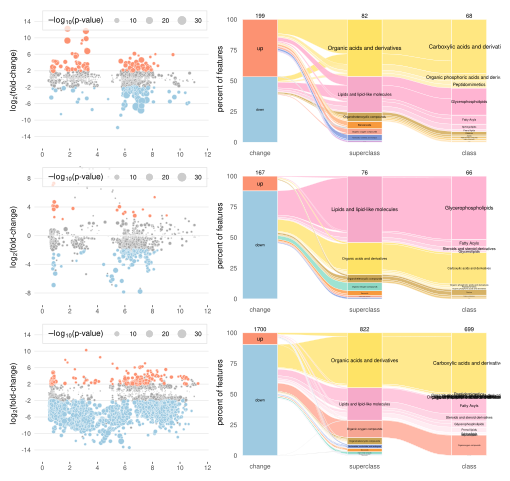

In [19]:
# Combine plots for all stages
diffAbs_plot <- (veg_cloud + veg_alluvial + plot_layout(widths = c(1, 1.5))) /
                (stv_cloud + stv_alluvial + plot_layout(widths = c(1, 1.5))) /
                (fbs_cloud + fbs_alluvial + plot_layout(widths = c(1, 1.5)))

# Define save path
save_path_svg <- file.path(wd, "04_results", "img", "svg", "plot_diffAbs_cloud_alluvial.svg")

# Create directory if it doesn’t exist
folder_path <- dirname(save_path_svg)
if (!dir.exists(folder_path)) dir.create(folder_path, recursive = TRUE)

# Save as SVG
ggsave(
  filename = save_path_svg,
  plot     = diffAbs_plot,
  width    = 180, height = 170, units = "mm",
  bg       = "transparent",
  device   = svglite
)

# Display the SVG
display_svg(file = save_path_svg)